### 笔记说明：不会讲解 pyTorch 库的功能用法，不理解的问 Ai 是什么，为什么，代码范例。


In [6]:
from importlib.metadata import version
print("torch version:", version("torch"))

torch version: 2.10.0


# 1.1 **一个没有可训练权重的简单自注意力机制**
#### 让我们从实现一个简化版的自注意力开始，不包含任何可训练权重。

#### 考虑以下输入句子，已经嵌入为三维向量

In [1]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

- #### 我们一共有 6 个token(单词)
- #### - 每个 token 是一个三维向量

## **第一步**：实现自注意力的第一步是计算中间值ω

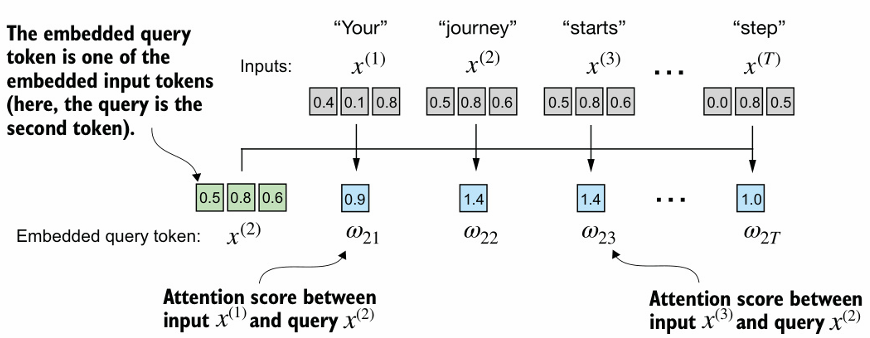

In [2]:
query = inputs[1]  # 2nd input token is the query

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query) # dot product (transpose not necessary here since they are 1-dim vectors)

print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


## 代码讲解 --
- #### 中间值：计算 查询标记 与 每个输入标记 之间的中间注意力分数。即是 通过计算查询 x(2) 与每个其他输入标记的 **点积** 来确定这些分数
#### attn_scores_2[i] = torch.dot(x_i, query)
- #### 查询向量 query [0.55, 0.87, 0.66] 与 每一个 输入向量 x_i 的 点积
#### 计算出的注意力分数为：tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865]) 

### **理解点积**: 将两个 向量 逐元素相乘，然后将结果相加。
#### 代码范例：第一行 向量 与 第二行 向量 的点积，都是同维度，同长度。

In [3]:
res = 0.
for idx, element in enumerate(inputs[0]):
    res += inputs[0][idx] * query[idx]

print(res)
print(torch.dot(inputs[0], query))

tensor(0.9544)
tensor(0.9544)


## **第二步**：将未归一化的注意力得分( ω )归一化，使其总和为 1。

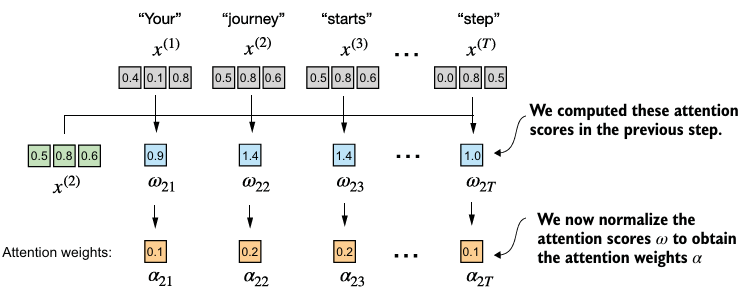

In [4]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()

print("Attention weights:", attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())

Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


## 代码讲解 --
- #### 归一化：把每个 token 的注意力分数转换为权重，保证所有权重加起来 = 1
#### attn_scores_2 / attn_scores_2.sum()
- #### 注意力分数 tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865]) 每一个 注意力分数 除以 注意力分数总和 tensor(6.5617)
#### 

#### 建议使用建议使用softmax函数进行归一化。
#### 好处：1.处理极端值时表现更好 2.训练期间提供更有利的梯度属性。
#### 下面的代码是一个简单的softmax实现(简单实现方法对于过大或过小的输入值都可能由于溢出和下溢问题而出现数值不稳定问题)：

In [5]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_scores_2)

print("Attention weights:", attn_weights_2_naive)
print("Sum:", attn_weights_2_naive.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


#### 建议使用 PyTorch 实现的 softmax 函数，该函数针对性能进行了高度优化：

In [9]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)

print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


## 最后一步：
### 通过将嵌入的输入标记 与注意力权重相乘来计算上下文向量 ，并将结果向量相加

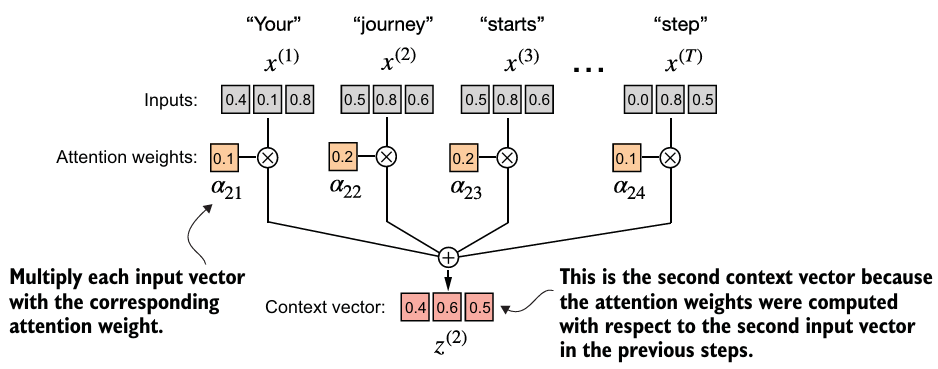

In [10]:
query = inputs[1] # 2nd input token is the query

context_vec_2 = torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i]*x_i

print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


# 1.2  计算所有输入标记的注意权重
#### 到目前为止，我们已经计算了输入2的注意权重和上下文向量。现在让我们扩展这个计算以计算所有输入的注意权重和上下文向量。
